# Inverzija Radonove transformacije uz filtriranje
## Inverzni problemi i strojni vid - drugi projektni zadatak (tema 2)


### Doris Đivanović

## Radonova transformacija i računalna tomografija (CT)

Općenito u matematici, **Radonova transformacija** preslikava funkciju $f$ u njezine linijske integrale po pravcima $L(\theta, s)$:
$$
(Rf)(\theta, s) = \int_{x \cdot \theta = s} f(x) \, d\ell(x),
$$
gdje je 
- $\theta = (\cos\phi, \sin\phi)$ jedinični vektor koji definira kut,
- $s$ udaljenost od ishodišta do pravca,
- $d\ell(x)$ integracija duž pravca,
- $x \in \mathbb{R}^2$.

U **računalnoj tomografiji (CT)** Radonova transformacija je matematički model širenja $X$-zraka kroz objekt. Svaka $X$-zraka mjeri linijski integral koeficijenta slabljenja (atenuacije) duž svoje putanje, dakle izmjereni podaci su linijski integrali nepoznate funkcije (dakle, na primjer, koeficijenta atenuacije). 

U tom se kontekstu Radonova transformacija ponekad naziva i **Roentgenova transformacija**. Naziv *Roentgenova transformacija* naglašava fizikalnu interpretaciju, dakle slabljenje $X$-zraka duž putanja, a naziv *Radonova transformacija* naglašava matematičku interpretaciju, dakle linijski integral funkcije. 

Matematički, za funkciju, tj. **sliku**, $f(x, y)$, Radonova transformacija za kut $\theta$ i položaj detektora $s$ je:
$$
(Rf)(\theta, s) = \int_{-\infty}^{\infty} f(s\cos\theta - t\sin\theta, \; s\sin\theta + t\cos\theta) \, dt,
$$
gdje je:
- $\theta$ – kut projekcije (rotacija *scannera* oko objekta),
- $s$ – pomak duž detektora (udaljenost od središta),
 
a integral predstavlja ukupnu vrijednost funkcije $f$, tj. ukupno slabljenje $X$-zrake, duž pravca definiranog s  $(\theta, s)$.

CT *scanneri* mjere ove integrale za velik broj kutova $\theta$ i položaja $s$. Za svaki kut $\theta$ dobiva se jedna projekcija. Prikupljanjem projekcija za sve kutove $\theta$ dobiva se takozvani **sinogram**, dvodimenzionalni skup podataka. Svaka točka sinograma odgovara mjerenju za jednu $X$-zraku. 

Naziv *sinogram* dolazi od činjenice da za jednu točka objekta, tj. slike, skup njezinih projekcija za različite kutove $\theta$ čini sinusoidu.

Naime, neka je jedan svijetli piksel na slici točkasti objekt s položajem $(x_0, y_0)$. Za svaki kut $\theta$, detektor mjeri njegovu udaljenost od ishodišta duž smjera $\theta$
$$
s(\theta) = x_0 \cos\theta + y_0 \sin\theta,
$$
a to je upravo jednadžba sinusoide u varijabli $\theta$.

Dakle, skup projekcija, tj. Radonova transformacija, jedne točke daje sinusoidu na sinogramu. Intuitivno, Radonova transformacija jednog pravca daje *traku* sinusoida na sinogramu, itd.

## Inverzija Radonove transformacije

U računalnoj tomografiji, dakle, za nepoznatu sliku $f(x)$ **izmjereni podaci** su skup njezinih linijskih integrala, dakle njezina Radonova transformacija, odnosno skup njezinih projekcija za sve promatrane kutove $\theta$, dakle pripadni sinogram
$$g(\theta, s) = (Rf)(\theta, s).$$ 

Glavni cilj i problem računalne tomografije je **rekonstruirati nepoznatu sliku** $f(x)$ iz njezine poznate Radonove transformacije, odnosno sinograma. Dakle, glavni je cilj **invertirati Radonovu transformaciju**.

Ovo je dakle, dobar **primjer inverznog problema**.

### Fourierov *slice* teorem

Inverzija Radonove transformacije zasniva se na *Fourier Slice* teoremu:
$$
\hat{f}(\omega \theta) = \widehat{(Rf)}(\theta, \omega),
$$
gdje je
- $\hat{f}$ 2D Fourierova transformacija slike $f(x)$,
- $\widehat{(Rf)}$ 1D Fourierova transformacija projekcije,
- $\theta$ smjer projekcije,
- $\omega$ varijabla frekvencije.

Interpretacija: 1D Fourierova transformacija projekcije za kut $\theta$ daje vrijednosti 2D Fourierove transformacije slike duž linije koja prolazi kroz ishodište u smjeru $\theta$. 

Dakle, Fourierov *slice* teorem kaže da 1D Fourierova transformacija jedne projekcije odgovara jednom *slice*-u kroz 2D Fourierovu transformaciju slike. Stoga, prikupljanjem više takvih projekcija, za različite kutove, može se uzorkovati 2D Fourierova transformacija slike. Tada je inverzijom 2D Fourierove transformacije moguća **rekonstrukcija** slike.

### Filtrirana inverzna projekcija (FBP)

Međutim, 1D Fourierova transformacija svake projekcije oslabljena je za faktor $1/|\omega|$, gdje $|\omega|$ predstavlja apsolutnu frekvenciju (magnitudu). Stoga je prije inverzije potrebno korigirati taj utjecaj i kompenzirati to slabljenje. Kako bi se to napravilo, potrebno je, prije inverzije, 1D Fourierovu transformaciju svake projekcije pomnožiti faktorom $|\omega|$, dakle
$$\hat p_f(\omega) = |\omega|\hat p (\omega),$$
gdje je $\hat p (\omega)$ 1D Fourierova transformacija projekcije. Kažemo da se svaka projekcija filtrira takozvanim ***ramp* filterom**.

Stoga, za inverziju Radonove transformacije koristi se **filtrirana inverzna projekcija** (*Filtered Backprojection* - FBP):
$$
f(x) = \int_{0}^{\pi} \big( (h * (Rf)(\theta, \cdot)) \big)(x \cdot \theta)\, d\theta,
$$
gdje je
- $h(s)$ *ramp* filter (s Fourierovom transformacijom $|\omega|$),
- $*$ oznaka za 1D konvoluciju u koordinati detektora $s$,
- $(Rf)(\theta, s)$ su projekcije.

Filtrirana inverzna projekcija polazi od podataka iz kojih želimo dobiti rekonstrukciju, dakle od Radonove transformacije $(Rf)(\theta, s)$, odnosno od skupa projekcija za svaki promatrani kut $\theta$, dakle od sinograma $g(\theta, s)$. 

Najprije se računa 1D Fourierova transformacija svake projekcije te se na nju primjenjuje *ramp* filter (ili neka njegova modifikacija), a zatim se radi inverzna Fourierova transformacija filtrirane projekcije:

$$rFFT \quad \longrightarrow \quad \text{\textit{ramp}:} \ \ * |\omega| \quad \longrightarrow \quad irFFT.$$

Sljedeći korak je takozvana ***inverzna projekcija*** svake filtrirane projekcije *natrag* na sliku. Inverzna projekcija projicira izmjerene podatke *natrag* u prostor originalnih podataka, tj. na sliku. Kopira projekciju za svaki kut $\theta$ *natrag* na sliku preko cijele slike duž smjera odgovarajućih *X*-zraka, te akumulira sve inverzne projekcije. Kaže se da inverzna projekcija *razmazuje* projekcije po slici. 

Ovime se dobiva eksplicitna formula za **inverziju Radonove transformacije** koja je **stabilna** i efikasna u praksi.

### Inverzna projekcija bez prethodnog filtriranja

Ukoliko se inverzna projekcija provede bez prethodnog filtriranja u Fourierovoj domeni, dobivena rekonstrukcija bit će jako mutna, bez oštrih rubova i naglih prijelaza. Rubovi na slici bit će *razmazani* u odgovarajućim smjerovima. Naime, iz izmjerenih podataka nije poznato odakle iz objekta dolazi slabljenje (atenuacija), već je poznato samo ukupno slabljenje duž pravca. Stoga se inverznom projekcijom izmjereni podaci *razmazuju* po slici uniformno duž cijelog pravca. 

Na primjer, ukoliko se originalna slika sastoji od samo jednog svijetlog piksela, dakle točkovni je objekt, projekcije te točke za razne kutove, tj. Radonova transformacija te točke, zajedno daju jednu sinusoidu na sinogramu. Ukoliko se te projekcije inverzno projiciraju na sliku bez prethodnog filtriranja, bit će *razmazane* kao *pruge* preko slike, a njihovom akumulacijom će rekonstruirana točka izgledati kao mutna mrlja, a ne oštra točka.

Nadalje, pretpostavimo da imamo *X*-zraku pod kutom $\theta$ i mjerimo kolika je apsorpcija duž svakog pravca. Pri inverznoj projekciji kopiramo tu izmjerenu vrijednost duž cijelog pravca na slici. Ako ovo napravimo za puno različitih kutova, *razmazat* ćemo informaciju za svaku projekciju preko cijele slike. Originalni objekt bit će rekonstruiran, ali, budući da je svaka točka višestruko *razmazana* u svim smjerovima, rekonstrukcija će izgledati kao da je nastala konvolucijom originalne slike s nekom jezgrom za *zamućivanje*.

Formalno, sama inverzna projekcija, bez filtriranja, je:
$$BP = f(x) * \frac{1}{|x|},$$
gdje je $1/{|x|}$ filter koji zadržava glatke i mutne komponente, ali oslabljuje visoke frekvencije - detalje, oštre rubove i nagle prijelaze.

Dakle, sama inverzna projekcija, bez filtriranja, previše uzorkuje niske frekvencije, a premalo uzorkuje visoke.

Rekonstrukcija inverznom projekcijom bez prethodnog filtriranja je **nestabilna**.

### Filtriranje *ramp* filterom

*Ramp* filter je množenje faktorom $|\omega|$ i provodi se u Fourierovoj domeni, dakle na 1D Fourierovim transformacijama projekcija. On kompenzira $1/|\omega|$ slabljenje, odnosno, kada se primjenjuje prije inverzne projekcije, poništava djelovanje $1/|x|$ *blur* jezgre.

Dakle, *ramp* filter izaziva suprotan efekt od efekta same inverzne projekcije. On prigušuje niske frekvencije, dakle glatkoću i *zamućenost*, korigira *razmazivanje* i *zamućivanje* inverzne projekcije, dakle vraća oštrinu i razbistrava sliku, a pojačava visoke frekvencije, dakle vidljivost i oštrinu rubova i finih detalja.

Stoga, inverzna projekcija s prethodnim filtriranjem daje oštru i detaljnu, **vrlo korektnu rekonstrukciju**.

Ukoliko na domeni frekvencija nacrtamo graf funckije
$$H(\omega) = |\omega|,$$
on će, dakle, biti pravac koji se *podiže* iz nule. Zbog toga se ovaj filter naziva *ramp* filter.

### Apodizacija

U visokim frekvencijama nalazi se i šum (*noise*), pa *ramp* filter pojačava i šum, koji kod same inverzne projekcije nije bio prisutan. 

Kako bi se spriječilo da primjena *ramp* filtera previše pojača šum, u praksi se *ramp* filter gotovo uvijek množi nekom glatkom *window* funkcijom. *Window* funkcije prigušuju i ublažavaju šum visoke frekvencije, dakle poništavaju pojačavanje šuma od strane *ramp* filtera, a čuvaju visinu rezolucije, tj. oštrinu. Neke poznate *window* funkcije koje tako djeluju su Hannova i kosinusna.

Primjena *window* funkcija naziva se **apodizacija**.

## Problem unaprijed

U računalnoj tomografiji Radonova transformacija slike $f(x)$ definira se, dakle, kao:
$$
(Rf)(\theta, s) = \int_{x \cdot \theta = s} f(x) \, d\ell(x),
$$
gdje je
- $\theta = (\cos\phi, \sin\phi)$ kut projekcije,
- $s$ – pomak, pozicija detektora (udaljenost od središta),
 
a, za fiksne $\theta$ i $s$, integral predstavlja ukupnu vrijednost funkcije $f$, tj. ukupno slabljenje $X$-zrake, duž pravca definiranog s  $(\theta, s)$.

Radonovu transformaciju **poznate slike** $f(x)$, $(Rf)(\theta, s)$, možemo izračunati na sljedeći način:

1. Rotiranjem slike za kut $-\theta$ - ovime smjer projekcije odgovara stupcima koordinatne *rešetke* slike, stupci su paralelni pravcima $x\cdot\theta = s$.

2. Sumiranjem po stupcima - sumiranje vrijednosti piksela duž svakog stupca daje integral po pravcu kroz objekt za taj kut, dakle daje 1D projekciju za taj $\theta$.

3. Napraviti ovo za svaki kut $\theta$, čime se dobiva skup projekcija koje čine **sinogram**.
   
Ovo je standardna implementacija Radonove transformacije **diskretizacijom**. U kontinuiranom slučaju, projekcija je integral duž pravca, a ovdje **integral aproksimiramo** rotacijom slike te sumiranjem vrijednosti piksela duž svih stupaca, dakle sumom vertikalnih *traka*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

### Podaci

Kreirat ćemo testni objekt sličan Shepp-Logan fantomu, koji je standardni testni objekt u tomografiji. Slika će se sastojati od velike elipse koja predstavlja glavu, manje elipse koja predstavlja regiju mozga i tamne elipse u unutrašnjosti. Jednadžba svake elipse dana je s:
$$\bigg(\frac{X - x_0}{a}\bigg)^2 + \bigg(\frac{Y - y_0}{b}\bigg)^2 \leq 1,$$
gdje je $(x_0, y_0)$ središte elipse, a $a$ i $b$ su duljne poluosi.

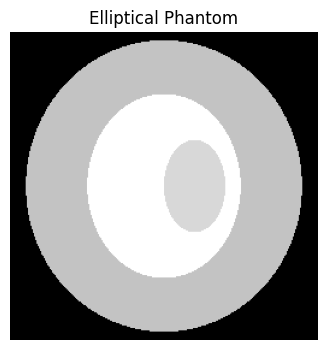

In [2]:
def ellipse_phantom(n = 256):

    # kreiranje resetke koordinata [-1,1] x [-1,1]
    Y, X = np.mgrid[-1 : 1 : n*1j, -1 : 1 : n*1j]

    phantom = np.zeros((n, n), dtype=np.float32)

    # elipsa za glavu
    # Jednadzba elipse: (X/a)^2 + (Y/b)^2 <= 1
    mask1 = ((X/0.9)**2 + (Y/0.95)**2) <= 1
    phantom[mask1] += 1.0   # intenzitet = 1 (svijetlo)

    # elipsa za regiju mozga
    mask2 = ((X/0.5)**2 + (Y/0.6)**2) <= 1
    phantom[mask2] += 0.3   # intenzitet = 0.3 (sivo)

    # unuatarnja elipsa
    mask3 = (((X-0.2)/0.2)**2 + (Y/0.3)**2) <= 1
    phantom[mask3] -= 0.2   # intenzitet = -0.2 (tamnije)

    return phantom

# generiranje slike-fantoma velicine n x n
x_true = ellipse_phantom(256)

# vizualizacija dobivene slike
plt.figure(figsize = (4, 4))
plt.imshow(x_true, cmap = "gray")
plt.title("Elliptical Phantom")
plt.axis("off")
plt.show()

### Konstrukcija sinograma iz poznate slike

Sada, gore (sekcija *Problem unaprijed*) opisanim i argumentiranim algoritmom implementiramo računanje Radonove transformacije, tj. konstrukciju sinograma, za upravo kreirani fantom.

Kako rotiranjem ne bismo odrezali dijelove slike, najprije kreiramo *padded* verziju originalne slike. Kako bi bilo koja rotacija originalne slike *ostala* unutar dimenzija *padded* slike, kreirat ćemo *padded* sliku dimenzije $\sqrt{2}\cdot n$, odnosno $\lceil \sqrt{2}\cdot n \rceil$, gdje je $n$ dimenzija originalne slike.

Kod je vrlo detaljno komentiran, pa trenutno ovdje izostavljamo opis, koji uključuje i opis egzaktne strukture dobivenog sinograma.

In [3]:
from scipy.ndimage import rotate

def radon_parallel(img, thetas, pad = True):
    
    # n = dimenzija originalne slike
    n = img.shape[0]

    # kako rotiranjem ne bismo odrezali dijelove slike,
    # radimo padding originalne slike
    if pad:
        # odabrati velicinu padded slike takvu da 
        # padded slika sadrzi cijelu rotiranu originalnu sliku za svaki kut theta
        # ===> approx. sqrt(2) * n, tj. ceiling od toga
        m = int( np.ceil( np.sqrt(2) * n ) )
        # padw = za koliko treba prosiriti originalnu sliku u svakom smjeru prema van
        padw = (m - n) // 2
        # padding mode = constant ===> padding nulama 
        img = np.pad(img, ((padw, padw), (padw, padw)), mode = 'constant')

    # konstrukcija sinograma - 2D polje 1D projekcija za svaki kut theta
    # dinamicka konstrukcija - 1D projekcije za pojedini kut theta bit ce vektori-retci sinograma
    sinogram_rows = []
    # racunanje 1D projekcije za svaki kut theta - diskretna aproksimacija
    for theta in thetas:
        # 1. korak: rotacija originalne slike za kut (- theta)  # radijani --> stupnjevi
        rotated_image_theta = rotate(img, angle = - np.degrees(theta), reshape = False, order = 1, mode = 'constant')
        # 2. korak: 1D projekcija za kut theta dobiva se kao vektor suma stupaca rotirane slike
        projection_theta = np.sum(rotated_image_theta, axis = 0)
        # upravo izracunata projekcija za kut theta dodaje se u listu vektora
        # koji ce se posloziti kao vektori-retci sinograma
        sinogram_rows.append(projection_theta)
        
    # 1D projekcije za pojedini kut theta slazu se kao vektori-retci sinograma
    # ===> sinogram je oblika [n_angles, detector_bins]
    sinogram = np.stack(sinogram_rows, axis = 0)
    
    return sinogram

### Vizualizacija sinograma

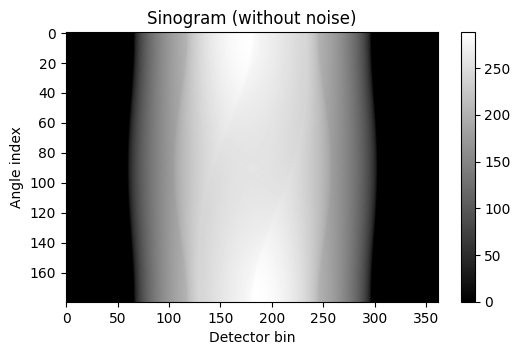

In [4]:
# odabir kutova theta - u rasponu od 0 do pi, uniformno
thetas = np.linspace(0, np.pi, 180, endpoint = False)  # 180 razlicitih kutova/pogleda

# racunanje sinograma - "model unaprijed"
sinogram_clean = radon_parallel(x_true, thetas)  # ovo je sinogram, tj. skup projekcija, bez suma, pa ga nazvati sinogram_clean

# vizualizacija dobivenog sinograma
plt.figure(figsize = (6, 3.5))
plt.imshow(sinogram_clean, cmap = "gray", aspect = "auto")
plt.title("Sinogram (without noise)")
plt.xlabel("Detector bin")
plt.ylabel("Angle index")
plt.colorbar(); # prikaz ljestvice vrijednosti i pripadnih intenziteta boje
plt.show()

Vidimo da sinogram za prethodno kreirani fantom s tri elipse izgleda kao deblji *snop* sinusoida. To je očekivano. Naime, kako je ranije objašnjeno, fantom koji se sastoji od samo jedne točke proizvodi jednu sinusoidu kao sinogram. Stoga, recimo, fantom od dvije točke proizvodi sinogram koji se sastoji od dviju sinusoida. Intuitivno, fantom koji se sastoji od elipse proizvest će sinogram koji izgleda kao *debeli snop* sinusoida.

### Dodavanje šuma s Gaussovom distribucijom na sinogram

Sada ćemo na prethodno dobiveni *originalni* sinogram dodati Gaussov šum, tj. šum koji ima Gaussovu distribuciju $\mathcal{N}(0, \sigma^2I)$.

Kao što je rečeno ranije, *ramp* filter primijenjen u Fourierovoj domeni pri filtriranoj inverznoj projekciji pojačava šum, pa ćemo ga za ovaj sinogram primijeniti s apodizacijskom funkcijom koja prigušuje to pojačanje.

In [5]:
# dodavanje Gaussova suma, sa standardnom devijacijom koja iznosi sigma, na sliku
def add_gaussian_noise(y, sigma):
    return y + sigma * rng.standard_normal(y.shape)

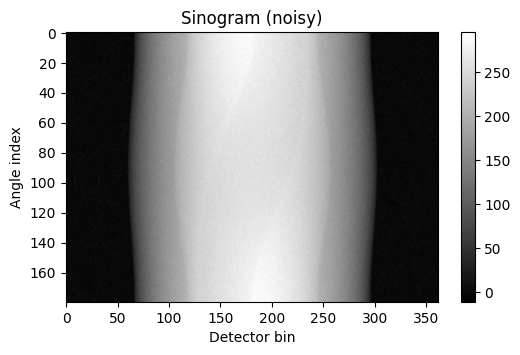

In [6]:
# postavljanje standardne devijacije Gaussova suma za sinogram
# tj. razine suma
sigma = 0.01 * np.max( np.abs(sinogram_clean) ) # npr. 1 % maksimalne projekcije

# dodavanje Gaussova suma na sinogram
sinogram_noisy = add_gaussian_noise(sinogram_clean, sigma)

# vizualizacija noisy sinograma
plt.figure(figsize = (6, 3.5))
plt.imshow(sinogram_noisy, cmap = "gray", aspect = "auto")
plt.title("Sinogram (noisy)")
plt.xlabel("Detector bin"); 
plt.ylabel("Angle index"); 
plt.colorbar(); 
plt.show()

### Usporedba originalnog i *noisy* sinograma

Sinograme bez i sa šumom usporedit ćemo računski i vizualno.

Računski, izračunat ćemo metrike kojima ćemo izmjeriti sličnost dvaju sinograma. Izračunat ćemo takozvane *Signal-to-Noise Ratio (SNR)* i *Peak-Signal-to-Noise-Ratio (PSNR)* metrike s vrijednostima u decibelima, koje se često koriste u obradi signala. Što su vrijednosti ovih metrika više (do oko $40\text{db}$), sličnost uspoređivanih objekata je veća.

Vizualno, paralelno ćemo vizulaizirati oba sinograma.

In [7]:
def snr(u, f):
    # Signal-to-Noise Ratio metrika
    num = np.sum(f**2)
    den = np.sum((u - f)**2) + 1e-12
    return 10 * np.log10( num / den )

def psnr(u, f):
    # Peak-Signal-to-Noise-Ratio metrika
    maxv = np.max(np.abs(f))
    # MSE = mean squared error = sredina kvadrata pogreske
    mse  = np.mean((u - f)**2) + 1e-12
    return 20 * np.log10( maxv / np.sqrt(mse) )

In [8]:
# racunanje SNR I PSNR metrika
print("SNR/PSNR of (noisy sinogram, noiseless sinogram):")
print("  SNR  :", snr(sinogram_noisy, sinogram_clean))
print("  PSNR :", psnr(sinogram_noisy, sinogram_clean))

SNR/PSNR of (noisy sinogram, noiseless sinogram):
  SNR  : 35.491568154304446
  PSNR : 40.00990480638437


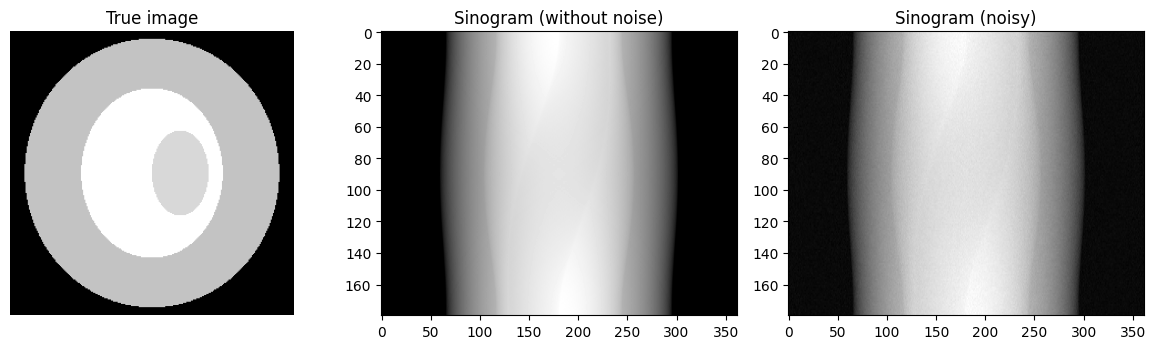

In [9]:
# paralelna vizualizacija u svrhu usporedbe
fig, ax = plt.subplots(1, 3, figsize = (12, 3.6))
ax[0].imshow(x_true, cmap = 'gray'); ax[0].set_title("True image"); ax[0].axis('off')
ax[1].imshow(sinogram_clean, cmap = 'gray', aspect = 'auto'); ax[1].set_title("Sinogram (without noise)")
ax[2].imshow(sinogram_noisy, cmap = 'gray', aspect = 'auto'); ax[2].set_title("Sinogram (noisy)")
plt.tight_layout();
plt.show()

## Implementacija filtrirane inverzne projekcije

### Računanje *ramp* filtera $|\omega|$ s eventualnom apodizacijom

Sada ćemo napisati funkciju za računanje svih vrijednosti potrebnih za primjenu *ramp* filtera, dakle za računanje vrijednosti
$$H(\omega) = |\omega|$$ 
za svaku normaliziranu frekvenciju $\omega$ iz pripadne domene frekvencija.

Kao što smo već rekli, u praksi se gotovo uvijek primjenjuje apodizacija, odnosno *ramp* filter se gotovo uvijek množi nekom glatkom *window* funkcijom, pa ćemo funkciju prilagoditi i za to.

Neke poznate *window* funkcije su Hannova i kosinusna.

Hannova *window* funkcija:
$$w(\omega) = 0.5 \,\Bigg[ 1 - \cos \Bigg( 2\pi \frac{\omega}{\omega_{\max}} \Bigg) \Bigg]$$

Kosinusna *window* funkcija:
$$w(\omega) = \cos \Bigg( \frac{\pi\omega}{2\omega_{\max}} \Bigg)$$

In [10]:
from numpy.fft import rfftfreq 

In [11]:
def ramp_filter(num_detector_bins, apodisation = 'hann'):
   
    # frekvencije u diskretnoj Fourierovoj transformaciji
    # realne frekvencije (omega) u domeni (rfft)
    freqs = rfftfreq(num_detector_bins)  # normalizirane frekvencije u [0, 0.5]

    # ramp filter = |omega|
    ramp = np.abs(freqs)

    if apodisation == 'hann':
        # Hannov prozor
        window = 0.5 * (1 - np.cos(2 * np.pi * freqs/freqs.max()))
        window[0] = 0.0
        ramp_filter = ramp * window

    elif apodisation == 'cosine':
        # kosinusni prozor
        window = np.cos( np.pi * freqs / (2*freqs.max()) )
        window[0] = 0.0
        ramp_filter = ramp * window
        
    else:
        ramp_filter = ramp
        ramp_filter[0] = 0.0
        
    return freqs, ramp_filter

### Usporedba vrijednosti *ramp* filtera sa i bez apodizacije

Kako bismo mogli nacrtati grafove pripadnih funkcija, gornja funkcija vraća i domenu frekvencija.

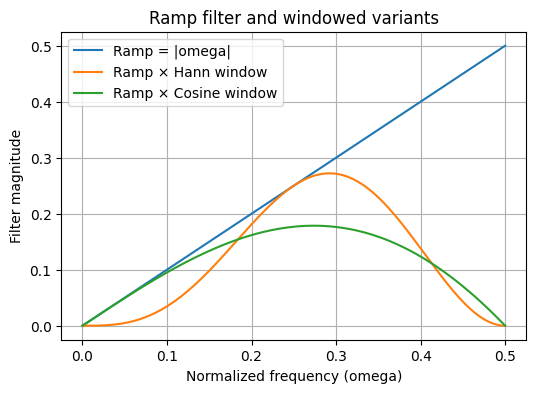

In [12]:
# npr. detektor duljine 256
num_detector_bins = 256

freqs, filter_ramp   = ramp_filter(num_detector_bins, apodisation = None)
_,     filter_ramp_hann   = ramp_filter(num_detector_bins, apodisation = 'hann')
_,     filter_ramp_cosine = ramp_filter(num_detector_bins, apodisation = 'cosine')

plt.figure(figsize = (6, 4))

plt.plot(freqs, filter_ramp, label = "Ramp = |omega|")
plt.plot(freqs, filter_ramp_hann, label = "Ramp × Hann window")
plt.plot(freqs, filter_ramp_cosine, label = "Ramp × Cosine window")

plt.xlabel("Normalized frequency (omega)")
plt.ylabel("Filter magnitude")

plt.title("Ramp filter and windowed variants")

plt.legend()
plt.grid(True)
plt.show()

Vrijednosti *ramp* filtera linearno rastu s porastom frekvencije, pa zato on jako pojačava visoke frekvencije. Rekonstrukcija slike je tada oštra, tj. visoke rezolucije, ali vrlo vjerojatno i s visokom razinom šuma, tj. smetnji. Graf *ramp* filtera je, dakle, pravac koji se *podiže* iz nule, *rampa*.

Kao što je već rečeno, *window* funkcije prigušuju i ublažavaju šum visoke frekvencije, dakle poništavaju pojačavanje šuma od strane *ramp* filtera, a čuvaju visinu rezolucije, tj. oštrinu. Stoga su grafovi *window* funkcija zaglađenije verzije *rampe*.

Može se vidjeti da Hannova *window* funkcija glatko umanjuje vrijednosti blizu frekvencije s vrijednošću $0.5$. Time *odreže* najviše frekvencije, pa je rekonstrukcija slike tada s manje šuma i smetnji, ali je i oštrina rubova donekle izgubljena.

Nadalje, može se vidjeti da kosinusna *window* funkcija prigušuje visoke frekvencije naglije nego Hannov, pa su rekonstrukcije tada još glađe, s manje šuma, ali i s primjetno glađim rubovima. 

### Inverzna projekcija s filtriranjem

Ukoliko provodimo filtriranje, najprije provodimo realni FFT za svaku projekciju, tj. za svaki redak sinograma, duž vektora detektora, dakle računamo 1D Fourierovu transformaciju svake projekcije, i preslikavamo je u Fourierovu domenu. Zatim, u Fourierovoj domeni provodimo filtriranje. Fourierovu transformaciju svake projekcije množimo *ramp* filterom s eventualnom apodizacijom, dakle faktorom $1/\omega \ \ (* \ window)$, dakle filtriramo je. Nakon toga, radimo inverzni FFT svake projekcije, čime dobivamo *filtrirani* sinogram.

Inverzna projekcija, dakle projiciranje filtriranih projekcija *natrag* u prostor originalnih podataka, *razmazivanjem* preko slike, svodi se na rotaciju za kut $\theta$ i sumaciju. 

Inverznu projekciju provodimo na sliku dimenzija originalne slike s *paddingom*. Najprije, za svaki kut $\theta$, tj. za svaku projekciju, kreiramo dvodimenzionalnu *prugu* odgovarajuće veličine, a zatim repliciramo pripadnu projekciju u tu *prugu*. Zatim, dobivenu *prugu* rotiramo za kut $+\theta$, kako bismo je *vratili* duž ispravnog smjera. Slika se konstruira dinamički, akumulacijom vertikalnih *pruga* za svaku projekciju. Akumulacijom vertikalnih *pruga* i množenjem s $\Delta\phi$, Riemannovom sumom aproksimira se integral.

Konačno, rekonstrukcija se dobiva izrezivanjem dijela nastale slike koji veličinom i položajem na slici s *paddingom* odgovara originalnoj slici.

In [13]:
from numpy.fft import rfft, irfft  # realni FFT, inverzni realni FFT

from scipy.ndimage import rotate

**Napomena.** 

Donja funkcija nazvana je `back_projection` i napisana je tako da se može upotrebljavati i za filtriranu i za nefiltriranu inverznu projekciju, kako bi se, na primjer, mogla upotrijebiti za usporedbu rekonstrukcija. U slučaju filtriranja, *ramp* filter s eventualnom apodizacijom kreira se neposredno prije poziva ove funkcije i prosljeđuje joj se kao parametar.

In [14]:
def back_projection(sinogram, thetas, filt = None):
    
    # broj kutova theta, tj. ukupan broj 1D projekcija
    # i broj detector bin-ova
    num_angles, num_detector_bins = sinogram.shape

    # 1. korak: (eventualno) filtriranje svake pojedine 1D projekcije (proj. za svaki kut theta)

    if filt is not None:
        
        # rFFT za svaku projekciju ,tj. za svaki redak sinograma  
        Sf  = rfft(sinogram, axis = 1)
        # mnozenje svakog retka , tj. 1D Fourierove transformacije svake projekcije,
        # ramp  filterom
        Sf  *= filt[None, :]  
        # inverzni rfft, realne filtrirane projekcije ==> filtrirani sinogram 
        sinogram = irfft(Sf, n = num_detector_bins, axis = 1)   

    # 2. korak: inverzna projekcija

    # priprema praznog "canvas-a" za inverznu projekciju
    # canvas velicine jednake velicini padded slike
    # m = dimenzija padded originalne slike = duljina detektora
    m = num_detector_bins                              
    out = np.zeros((m, m), dtype = np.float32)
    cx  = 0                              # we'll place strip across full width

    # "vracanje" (inverzna projekcija) svake pojedine filtrirane projekcije na canvas
    for i, theta in enumerate(thetas):
        
        # kreiranje vertikalne "pruge"
        strip = np.zeros_like(out)
        # kopiranje 1D projekcije u vertikalnu prugu - repliciramje projekcije u stupce za raspon redaka
        strip[:, cx : cx + num_detector_bins] = sinogram[i][None, :]   

        # rotiranje "pruge" za kut +theta da bi se projekcija "vratila" duz dobrog smjera
        rotated_strip = rotate(strip, angle = np.degrees(theta), reshape = False, order = 1, mode = 'constant')

        # canvas se popunjava akumulacijom "pruga" za svaku projekciju
        out += rotated_strip

    # velicina "koraka" izmedu vrijednosti kutova za aproksimaciju Riemannove sume 
    dtheta = (thetas[-1] - thetas[0]) / num_angles if num_angles > 1 else np.pi
    # aproksimacija integrala skaliranjem s velicinom "koraka"
    out *= dtheta 

    # izrezivanje iz "canvas-a" dijela koji odgovara originalnoj slici 
    # ====> trazena rekonstrukcija
    
    # dimenzija originalne slike
    n = x_true.shape[0]
    # n x n dio koji odgovara originalnoj slici uvucen je u padded sliku
    # za radijus padding-a
    start = (m - n) // 2
    x_reconstructed = out[start : start + n, start : start + n]
    
    return x_reconstructed
    
    """
        m = int(np.ceil(np.sqrt(2)*det))
        out = np.zeros((m, m), dtype=np.float32)
        cx = (m-det)//2
    """

### Rekonstrukcija slike inverznom projekcijom s filtriranjem i bez filtriranja

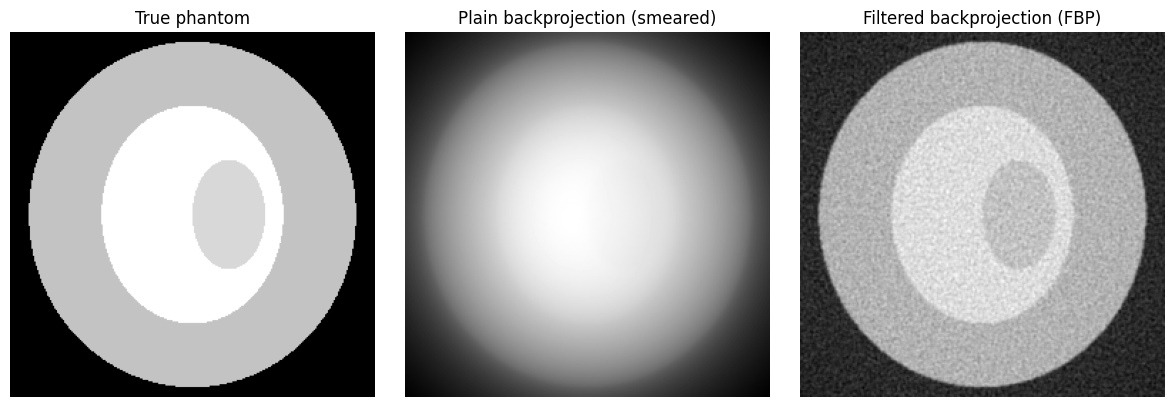

In [15]:
# rekonstrukcija slike iz sinograma inverznom projekcijom BEZ FILTRIRANJA
x_reconstructed_without_filtering = back_projection(sinogram_noisy, thetas, filt = None)

num_detector_bins = sinogram_noisy.shape[1]
# racunanje ramp filtera |omega| (+ eventualna window funkcija)
_, rampfilter = ramp_filter(num_detector_bins, apodisation = 'cosine')

# rekonstrukcija slike iz sinograma FILTRIRANOM inverznom projekcijom
x_reconstructed = back_projection(sinogram_noisy, thetas, filt = rampfilter)

# paralelna vizualizacija BP i FBP rekonstrukcije i originalne slike u svrhu usporedbe
fig, ax = plt.subplots(1, 3, figsize = (12, 4))
ax[0].imshow(x_true, cmap = "gray"); ax[0].set_title("True phantom"); ax[0].axis("off")
ax[1].imshow(x_reconstructed_without_filtering, cmap = "gray"); ax[1].set_title("Plain backprojection (smeared)"); ax[1].axis("off")
ax[2].imshow(x_reconstructed, cmap = "gray"); ax[2].set_title("Filtered backprojection (FBP)"); ax[2].axis("off")
plt.tight_layout(); 
plt.show()

In [16]:
# racunanje slicnosti BP rekonstrukcije s originalnim fantomom
print("BP reconstruction vs True image  —  SNR(dB):",  snr(x_reconstructed_without_filtering, x_true))
print("BP reconstruction vs True image  —  PSNR(dB):", psnr(x_reconstructed_without_filtering, x_true))

# racunanje slicnosti FBP rekonstrukcije s originalnim fantomom
print("FBP reconstruction vs True image  —  SNR(dB):",  snr(x_reconstructed, x_true))
print("FBP reconstruction vs True image  —  PSNR(dB):", psnr(x_reconstructed, x_true))

BP reconstruction vs True image  —  SNR(dB): -56.69958
BP reconstruction vs True image  —  PSNR(dB): -53.479
FBP reconstruction vs True image  —  SNR(dB): 11.344563
FBP reconstruction vs True image  —  PSNR(dB): 14.565148


Kao što je detaljno opisano ranije, samom inverznom projekcijom svaka se projekcija *razmazuje* *natrag* preko slike. Inverzna projekcija bez filtriranja daje rekonstrukciju koja je jako *zamućena* i *glatka*, bez vidljivih oštrih rubova, prijelaza i detalja. Preklapanja *razmazanih* *pruga* naglase ispravne oblike, npr. ovdje rubove elipsi, ali, budući da nema korekcije frekvencija, rekonstrukcija je mutna. Ovo zapravo nije prava inverzija, njome se dobiva samo mutna verzija originalnog fantoma. 

Dominiraju niske frekvencije, a visoke frekvencije nedostaju. Zbog toga su vidljivi odgovarajući intenziteti sive boje, ali detalji su izgubljeni.
Slika je glatka i nema šuma, što ljudskom oku bolje paše nego slika sa smetnjama, pa nam se može činiti da ova rekonstrukcija i nije tako loša, osim što je mutna. Međutim, rekonstrukcija dobivena s filtriranjem otkriva rubove i *geometriju*, i zapravo je sličnija originalnom fantomu, što se može vidjeti iz vrijednosti metrika.

Nadalje, kao što je detaljno opisano ranije, *ramp* filter pojačava visoke frekvencije, a to su rubovi, nagli i oštri prijelazi, kontrasti i razni fini detalji, korigirajući *zamućenje* koje uzrokuje inverzna projekcija. Međutim, u visokim frekvencijama nalazi se i šum, pa rekonstrukcija može izgledati *zrnato*, *pahuljasto* i sa smetnjama.  

Možemo vidjeti da je upravo dobivena rekonstrukcija FBP-om stvarno poprilično izoštrena, ali s više šuma nego rekonstrukcija nefiltriranim BP-om. Vrijednosti metrika koje uspoređuju rekonstrukciju s originalnim fantomom također nisu loše.

### Rekonstrukcija slike filtriranom inverznom projekcijom sa i bez apodizacije

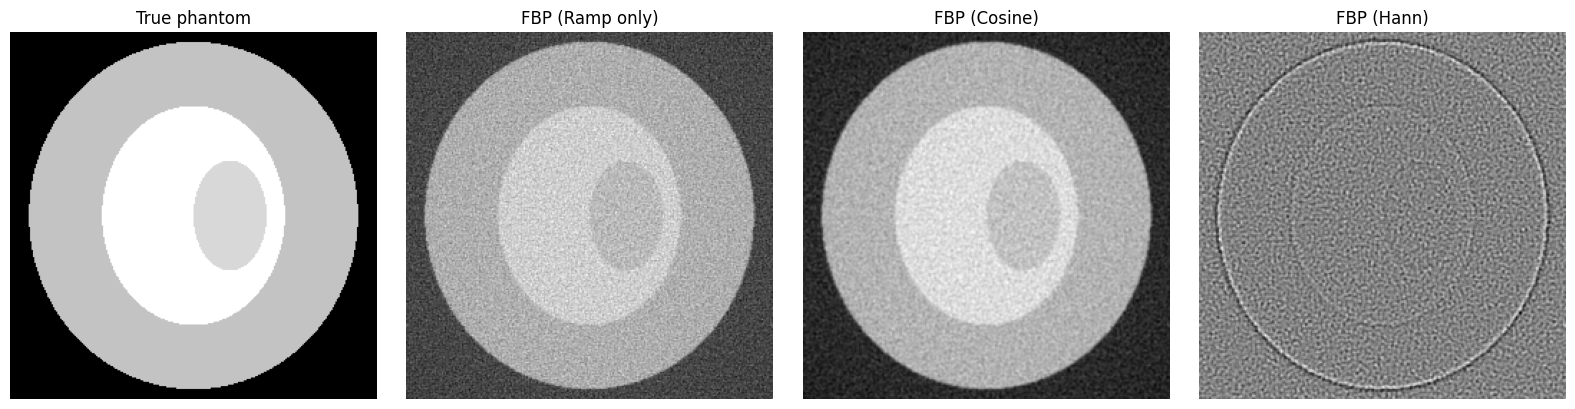

In [17]:
num_detector_bins = sinogram_noisy.shape[1]
# konstrukcija tri razlicita ramp filtera
_, ramp_only   = ramp_filter(num_detector_bins, apodisation = None)      
_, ramp_cosine = ramp_filter(num_detector_bins, apodisation = 'cosine')
_, ramp_hann   = ramp_filter(num_detector_bins, apodisation = 'hann')   

# rekonstrukcije slike iz sinograma inverznom projekcijom s pojedinim filtrima
x_reconstructed_with_ramp_only   = back_projection(sinogram_noisy, thetas, filt = ramp_only)
x_reconstructed_with_ramp_cosine = back_projection(sinogram_noisy, thetas, filt = ramp_cosine)
x_reconstructed_with_ramp_hann   = back_projection(sinogram_noisy, thetas, filt = ramp_hann)

# paralelna vizualizacija svih triju rekonstrukcija i originalne slike, u svrhu usporedbe
fig, axs = plt.subplots(1, 4, figsize = (16, 4))
axs[0].imshow(x_true, cmap = "gray"); axs[0].set_title("True phantom"); axs[0].axis("off")
axs[1].imshow(x_reconstructed_with_ramp_only, cmap = "gray"); axs[1].set_title("FBP (Ramp only)"); axs[1].axis("off")
axs[2].imshow(x_reconstructed_with_ramp_cosine, cmap = "gray"); axs[2].set_title("FBP (Cosine)"); axs[2].axis("off")
axs[3].imshow(x_reconstructed_with_ramp_hann, cmap = "gray"); axs[3].set_title("FBP (Hann)"); axs[3].axis("off")
plt.tight_layout()
plt.show()

In [18]:
# racunanje slicnosti svih triju rekonstrukcija s ORIGINALNIM fantomom
print("FBP Ramp-only  : SNR = %.3f, PSNR = %.3f" % (snr(x_reconstructed_with_ramp_only, x_true), psnr(x_reconstructed_with_ramp_only, x_true)))
print("FBP Cosine     : SNR = %.3f, PSNR = %.3f" % (snr(x_reconstructed_with_ramp_cosine, x_true), psnr(x_reconstructed_with_ramp_cosine, x_true)))
print("FBP Hann       : SNR = %.3f, PSNR = %.3f" % (snr(x_reconstructed_with_ramp_hann, x_true), psnr(x_reconstructed_with_ramp_hann, x_true)))

FBP Ramp-only  : SNR = 10.530, PSNR = 13.750
FBP Cosine     : SNR = 11.345, PSNR = 14.565
FBP Hann       : SNR = 0.007, PSNR = 3.227


Hannova apodizacija uglavnom prigušuje visoke frekvencije jače nego kosinusna, pa su, u odnosu na rekonstrukciju dobivenu filtriranom inverznom projekcijom s *ramp* filterom s kosinusnom apodizacijom, na pripadnoj rekonstrukciji izgubljeni određeni kontrasti, prijelazi i detalji.

Također, iz metrika je vidljivo da je rekonstrukcija dobivena filtriranom inverznom projekcijom s *ramp* filterom s kosinusnom apodizacijom sličnija originalnom fantomu od one za Hannovu apodizaciju.

Rekonstrukcije za sami *ramp* filter i za *ramp* filter s koisnusnom apodizacijom vrlo su slične, vizualno po svim promatranim svojstvima, ali i vrijednosti metrika s obzirom na originalni fantom su im jako slične.

## Rekonstrukcije iz ograničenih i nepotpunih podataka

CT *scanneri* u praksi standardno promatraju projekcije za *gusto* uzorkovane vrijednosti kutova iz punog raspona, dakle velik broj različitih projekcija iz cijelog *vidokruga*.

Ukoliko se promatra mali broj različitih kutova projekcija iz punog raspona, dakle *rijetko* uzorkovani kutovi, to se u literaturi naziva *sparse views* - *rijetki pogledi*.

Rekonstrukcija slike iz takvog sinograma nije dovoljno dobra, tj. daleko je lošija. Fourierova domena je premalo uzorkovana i na rekonstrukciji se pojavlju takozvani *artefakti* ili *pruge*.

Nadalje, ukoliko se projekcije ne promatraju za puni raspon kutova, već za samo neki manji dio raspona, rekonstrukcija slike iz takvog sinograma također nije dovoljno dobra. Na rekonstrukciji se također pojavlju takozvani *artefakti* ili *pruge*, a *pruge* su uglavnom tangencijalne na rubove rekonstruiranog objekta i šire se u smjerovima koji nisu promatrani. 

Dakle, obje spomenute redukcije podataka degradiraju rekonstrukciju i uzrokuju *artefakte*, no na nešto drugačiji način.

### *Rijetko* uzorkovanje kutova projekcija - *sparse views*

Najprije ćemo odabrati neki broj kutova projekcija koji je (znatno) manji od broja kutova koje smo prethodno bili odabrali za *gusto* uzorkovanje kutova iz raspona $[0, 180°)$, na primjer $20$ ili $30$. Zatim ćemo generirati uniformni uzorak odabrane veličine iz raspona $[0, 180°)$.

Konstruirat ćemo pripadni sinogram i primijeniti na njega Gaussov šum.

Rekonstruirat ćemo fantom iz dobivenog sinograma filtriranom inverznom projekcijom s *ramp* filterom i apodizacijom, zbog prethodno pokazanog, kosinusnom.

In [19]:
# odabir znatno manjeg broja kutova theta - u rasponu od 0 do pi, uniformno
# ===> "sparse views"
thetas_sparse = np.linspace(0, np.pi, 30, endpoint = False)  # npr. 30 razlicitih kutova

# racunanje sinograma - "model unaprijed"
sinogram_sparse = radon_parallel(x_true, thetas_sparse)

# dodavanje Gaussova suma na dobiveni sinogram
sinogram_sparse_noisy = add_gaussian_noise(sinogram_sparse, sigma)

num_detector_bins = sinogram_sparse.shape[1]
# racunanje ramp filtera |omega| (+ eventualna window funkcija)
_, rampfilter = ramp_filter(num_detector_bins, apodisation = 'cosine')

# rekonstrukcija slike iz sinograma filtriranom inverznom projekcijom
x_reconstructed_sparse = back_projection(sinogram_sparse_noisy, thetas_sparse, filt = rampfilter)

### Smanjeni raspon kutova projekcija - *limited angles*

Najprije ćemo odabrati neki raspon kutova projekcija koji je podskup raspona $[0, 180°)$, na primjer $[0, 120°)$. 

Prethodno smo već *gusto* uzorkovali kutove projekcija iz raspona $[0, 180°)$, te konstruirali pripadni sinogram i dodali mu Gaussov šum. Stoga ćemo iz već dobivene liste vrijednosti kutova izdvojiti samo one koje su u rasponu $[0, 120°)$. Zatim ćemo alocirati matricu dimenzija jednakih dimenzijama prethodno konstruiranog sinograma i potpuno je ispuniti nulama. Dakle, ponašat ćemo se kao da je ukupni broj različitih vrijednosti kutova projekcija jednak kao u prethodno dobivenom sinogramu. Konačno, na pripremljenu nulmatricu primijenit ćemo *masku* netrivijalnih vrijednosti kutova, a preostale će vrijednosti ostati nula. Dobivena matrica je pripadni sinogram.

Rekonstruirat ćemo fantom iz dobivenog sinograma filtriranom inverznom projekcijom s *ramp* filterom i apodizacijom, zbog prethodno pokazanog, kosinusnom.

In [20]:
# ograniceni kutovi, npr. [0, 120°)  ( thetas su bili kutovi u [0, 180°) )
# uzimamo kutove iz thetas, ali koji su unutar [0, 120°)
mask = (thetas >= 0) & (thetas < 2*np.pi/3)
# alokacija novog sinograma dimenzija jednakih dimenzijama sinogram_noisy sinograma
# i to potpuno ispunjenog nulama
sinogram_limited = np.zeros_like(sinogram_noisy)
# elementi sinograma koji odgovaraju kutovima iz thetas unutar [0, 120°) imaju odgov. vrijednosti,
# ostali ostaju nula
sinogram_limited[mask] = sinogram_noisy[mask] 

num_detector_bins = sinogram_limited.shape[1]
# racunanje ramp filtera |omega| (+ eventualna window funkcija)
_, rampfilter = ramp_filter(num_detector_bins, apodisation = 'cosine')

# rekonstrukcija slike iz sinograma filtriranom inverznom projekcijom
x_reconstructed_limited = back_projection(sinogram_limited, thetas, filt = rampfilter)

### Usporedba kvalitete rekonstrukcija na temelju *sparse view* sinograma i *limited angles* sinograma

Kvalitetu dobivenih rekonstrukcija ponovno ćemo usporediti računski i vizualno. 

Izračunat ćemo pripadne SNR i PSNR metrike u odnosu na originalni fantom.

Paralelno ćemo vizualizirati dobivene rekonstrukcije, a vizualizirat ćemo i pripadne pogreške u odnosu na originalni fantom, tj. slike koje su razlika rekonstrukcija fantoma i originalnog fantoma.

Također, vizualizirat ćemo i pripadne sinograme.

Sparse views  —  SNR: 9.333058  PSNR: 12.553644
Limited angles — SNR: 5.199028  PSNR: 8.419614


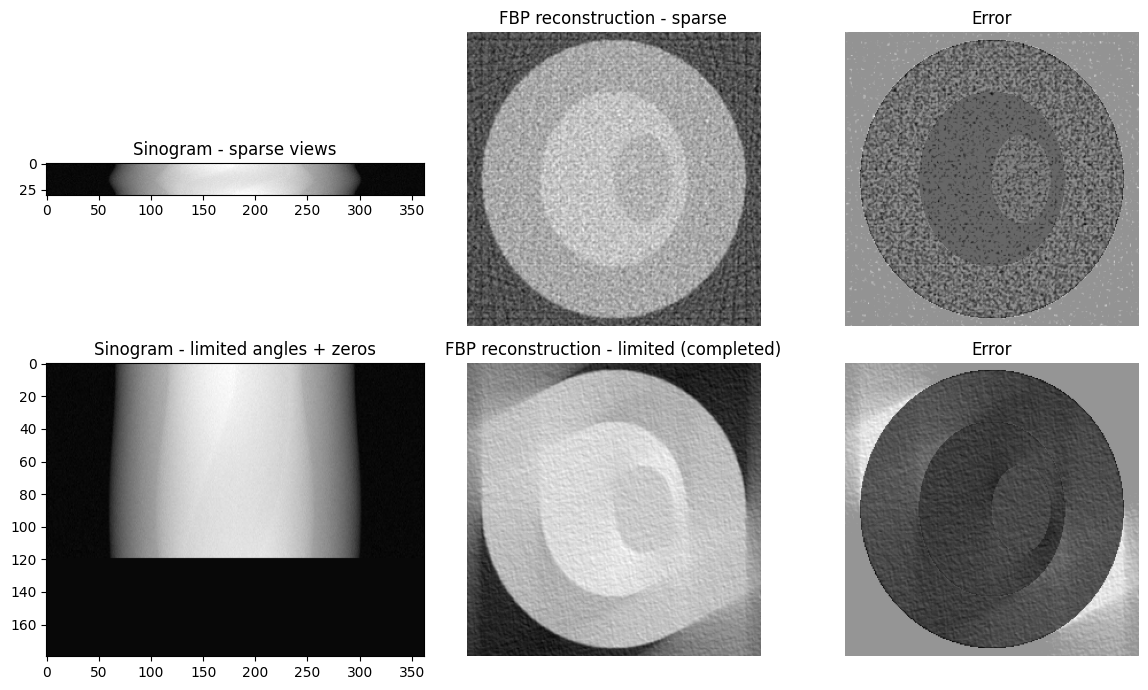

In [21]:
# usporedba kvalitete rekonstrukcija na temelju sparse view sinograma i limited angles sinograma

# metrike za usporedbu rekonstrukcija s originalnom slikom
print("Sparse views  —  SNR:", snr(x_reconstructed_sparse, x_true), " PSNR:", psnr(x_reconstructed_sparse, x_true))
print("Limited angles — SNR:", snr(x_reconstructed_limited, x_true), " PSNR:", psnr(x_reconstructed_limited, x_true))

# paralelna vizualizacija sinograma, dobivenih rekonstrukcija i pogreske u odnosu na originalnu sliku
fig, ax = plt.subplots(2, 3, figsize = (12, 7))

ax[0, 0].imshow(sinogram_sparse_noisy, cmap = 'gray', aspect = 'equal');    # vs. aspect = 'auto'
ax[0, 0].set_title("Sinogram - sparse views")

ax[0, 1].imshow(x_reconstructed_sparse, cmap = 'gray'); 
ax[0, 1].set_title("FBP reconstruction - sparse"); 
ax[0, 1].axis('off')

ax[0, 2].imshow(np.clip(x_reconstructed_sparse, 0, 1) - x_true, cmap = 'gray'); 
ax[0, 2].set_title("Error"); 
ax[0, 2].axis('off')

ax[1, 0].imshow(sinogram_limited, cmap = 'gray', aspect = 'auto');      
ax[1, 0].set_title("Sinogram - limited angles + zeros")

ax[1, 1].imshow(x_reconstructed_limited, cmap = 'gray'); 
ax[1, 1].set_title("FBP reconstruction - limited (completed)"); 
ax[1, 1].axis('off')

ax[1, 2].imshow(np.clip(x_reconstructed_limited, 0, 1) - x_true, cmap = 'gray'); 
ax[1, 2].set_title("Error"); 
ax[1, 2].axis('off')

plt.tight_layout(); 
plt.show()

Sinogrami su, dakle, pohranjeni kao matrice čiji retci odgovaraju pojedinim kutovima projekcija, a stupci odgovaraju *bin*-ovima detektora. Sinogram dobiven za znatno manji broj promatranih različitih kutova projekcija ima puno manje redaka nego sinogram dobiven za *gusto* uzorkovane kutove u rasponu $[0, 180°)$. Sinogram dobiven za smanjeni raspon kutova projekcija je prazan, tj. potpuno taman, u dijelu raspona $[0, 180°)$ iz kojeg nismo uzorkovali kutove projekcija, budući da smo pripadne vrijednosti postavili na nulu.

Nadalje, na gornjim rekonstrukcijama dobivenim iz, dakle, ograničenih i nepotpunih podataka stvarno se mogu uočiti *artefakti* i *pruge*.

Vidi se da rekonstrukcija fantoma na temelju sinograma za *rijetko* uzorkovane kutove sadrži primjetan šum i *zrnata* je, a vide se i pruge koje se zvjezdasto šire od vanjskih rubova rekonstruiranog objekta.

Na rekonstrukciji fantoma na temelju sinograma za ograničen i smanjen raspon kutova projekcija mogu se vidjeti pruge tangencijalne na rubove rekonstruiranog objekta. Rubovi svih triju rekonstruiranih elipsa su *razmazani* i *zamrljani* duž tangencijalnih linija u smjerovima koji odgovaraju kutovima projekcija koje nismo uzeli u obzir, tj. dijelovi rekonstrukcije fantoma su *zamrljani*  i rastegnuti u smjerovima koje nismo uzorkovali. Ovo je klasičan i očekivan ishod za umanjeni raspon kutova projekcija.

Također, vrijednosti SNR i PSNR metrika za ove rekonstrukcije su znatno manje nego za rekonstrukciju na temelju sinograma dobivenog za *gusto* uzorkovane kutove projekcija duž raspona $[0, 180°)$, kao što je i očekivano.

### Eventualna redukcija *artefakata*

Kako bi se umanjili i izbjegli *artefakti* na rekonstrukciji, sinogram nastao iz ograničenih i nepotpunih podataka može se, prije provođenja pripadne filtrirane inverzne projekcije, *zagladiti* uz granice nepostojećih podataka, tj. mogu se zagladiti *skokovi* s *popunjenih* dijelova na *prazne* dijelove sinograma.

# Literatura

- prof. dr. sc. Luka Grubišić, nastavni materijali iz kolegija Inverzni problemi i strojni vid, ak. god. 2024./2025., PMF - MO, Zagreb
- A.C. Kak and M. Slaney, *Principles of Computerized Tomographic Imaging*, SIAM, 2001 (Chapter 2–3).  
- F. Natterer, *The Mathematics of Computerized Tomography*, SIAM, 2001.  
- E.T. Quinto, *An introduction to X-ray tomography and Radon transforms*, in: 
  *Mathematics and Algorithms of CT (TODD notes)*, Ch. 8, 2008.  
- https://en.wikipedia.org/wiki/Signal-to-noise_ratio
- https://en.wikipedia.org/wiki/Window_function